In [66]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [67]:
# Read database
df = pd.read_csv('cardio_train.csv', sep = ';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [68]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [69]:
list(df.columns)

['id',
 'age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

In [70]:
#no. of recodrds
df.shape[0]

70000

In [71]:
#no. of Coloums/Features
df.shape[1]

13

In [72]:
#inormation about database
df.info()
df['height'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


count    70000.000000
mean       164.359229
std          8.210126
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64

In [73]:
#describe database
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


### Data Preprocessing

In [74]:
#missing values
pd.DataFrame([df.isnull().sum()])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [75]:
#dublicat row 
print(df.duplicated().sum())

0


In [76]:
#unique values
pd.DataFrame([ df.nunique(), df.dtypes ])

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,70000,8076,2,109,287,153,157,3,3,2,2,2,2
1,int64,int64,int64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64


In [77]:
# Feature type
TARGET = 'cardio'
INPUT_FEATURES = ['age','gender','height','weight','ap_hi','ap_hi','cholesterol','gluc','smoke','alco','active']

In [78]:
df = df.drop(columns = 'id')

In [79]:
list(df.columns)

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

In [80]:
#dublicat row 
print(df.duplicated().sum())

24


In [81]:
df.drop_duplicates(inplace=True)

In [82]:
print(df.duplicated().sum())

0


In [83]:
print(df.isnull().sum())

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### EDA AND VISUALIZATION

In [84]:
#class Distribution
class_dist = df['cardio'].value_counts().reset_index()
class_dist.columns = ['Class', 'Count']
class_dist['Class'] = class_dist['Class'].map({0: 'No Disease', 1: 'Disease'})
class_dist['Percentage'] = (class_dist['Count'] / len(df) * 100)
class_dist

,Class,Count,Percentage
0,No Disease,35004,50.022865
1,Disease,34972,49.977135


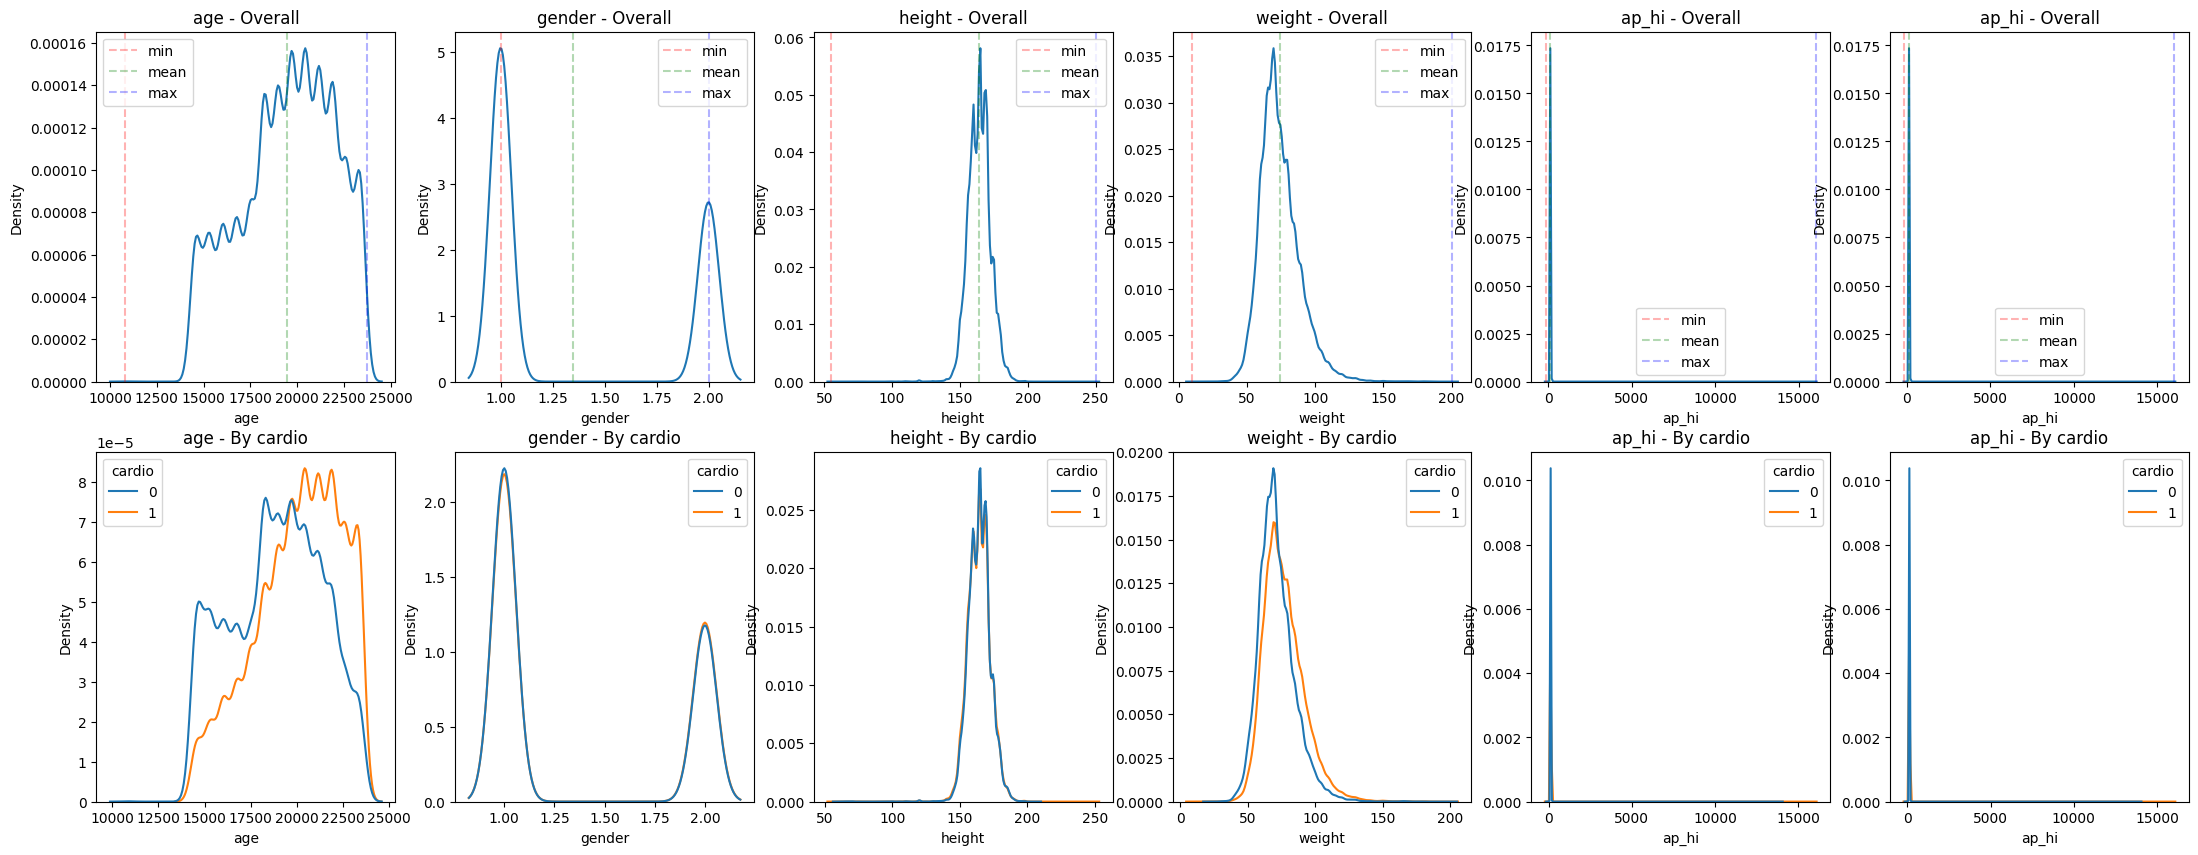

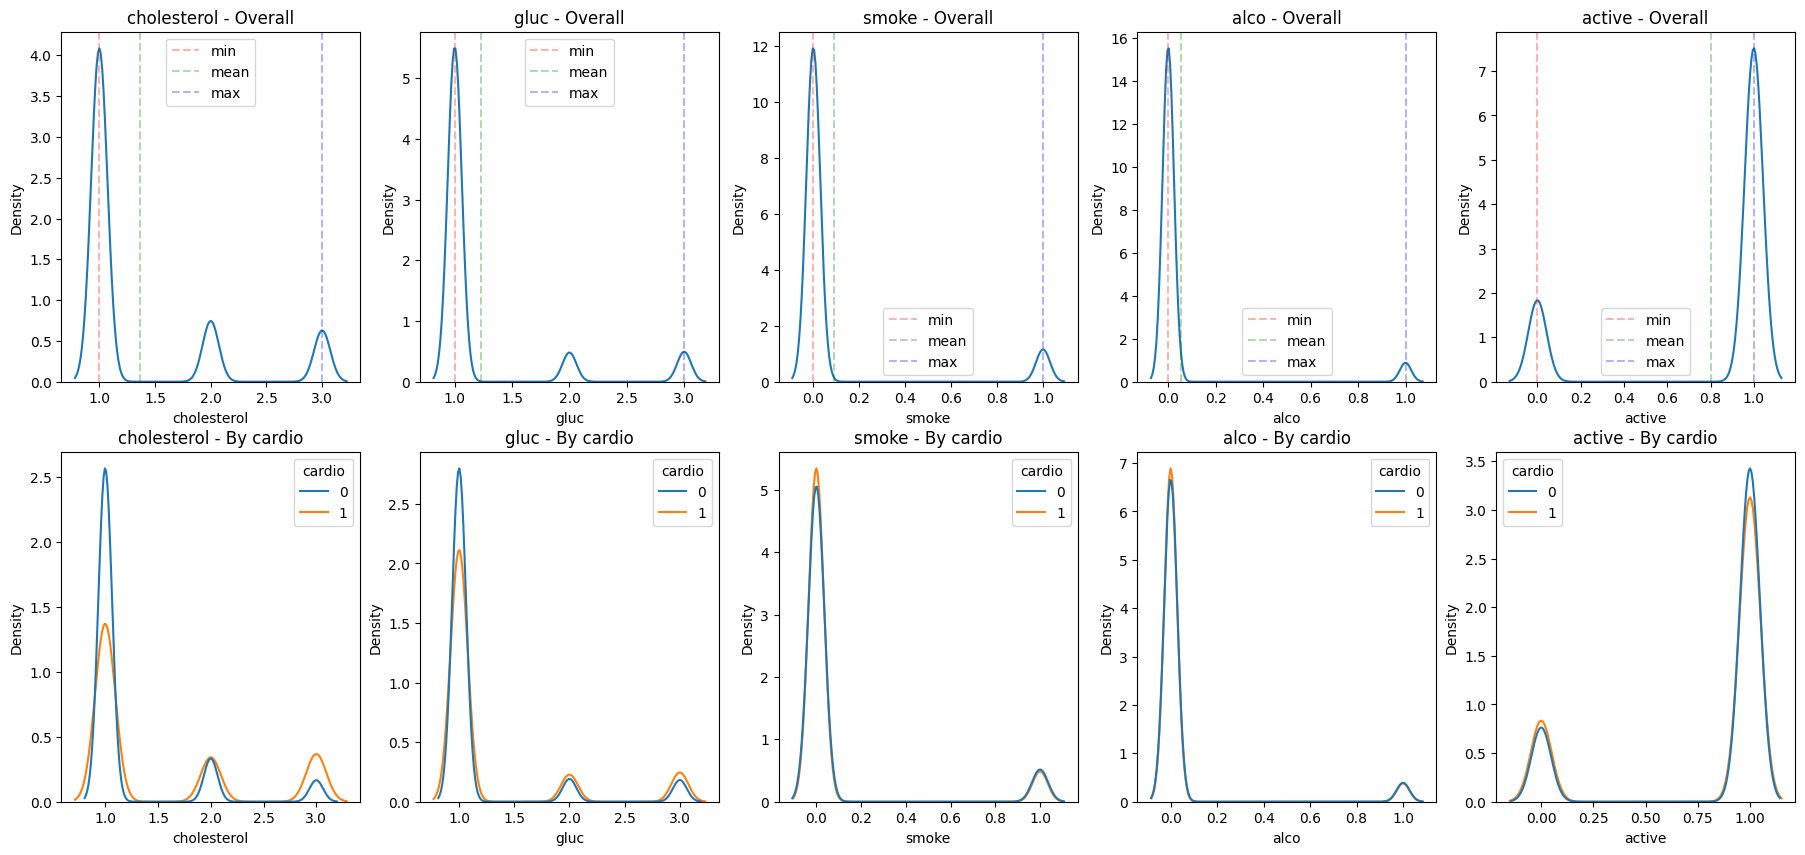

In [85]:
ROW_WIDTH = 6

for i, feature in enumerate(INPUT_FEATURES):

    if i % ROW_WIDTH == 0:
        plt.figure(figsize=(27, 10))

    plt.subplot(2, ROW_WIDTH, (i % ROW_WIDTH) + 1)
    plt.title(f"{feature} - Overall")
    sns.kdeplot(data=df, x=feature)

    plt.axvline(df[feature].min(), color='r', linestyle='--', alpha=0.3, label='min')
    plt.axvline(df[feature].mean(), color='g', linestyle='--', alpha=0.3, label='mean')
    plt.axvline(df[feature].max(), color='b', linestyle='--', alpha=0.3, label='max')
    plt.legend()

    plt.subplot(2, ROW_WIDTH, (i % ROW_WIDTH) + 1 + ROW_WIDTH)
    plt.title(f"{feature} - By {TARGET}")
    sns.kdeplot(data=df, x=feature, hue=TARGET, palette='tab10')

    if (i + 1) % ROW_WIDTH == 0:
        plt.show()

if len(INPUT_FEATURES) % ROW_WIDTH != 0:
    plt.show()

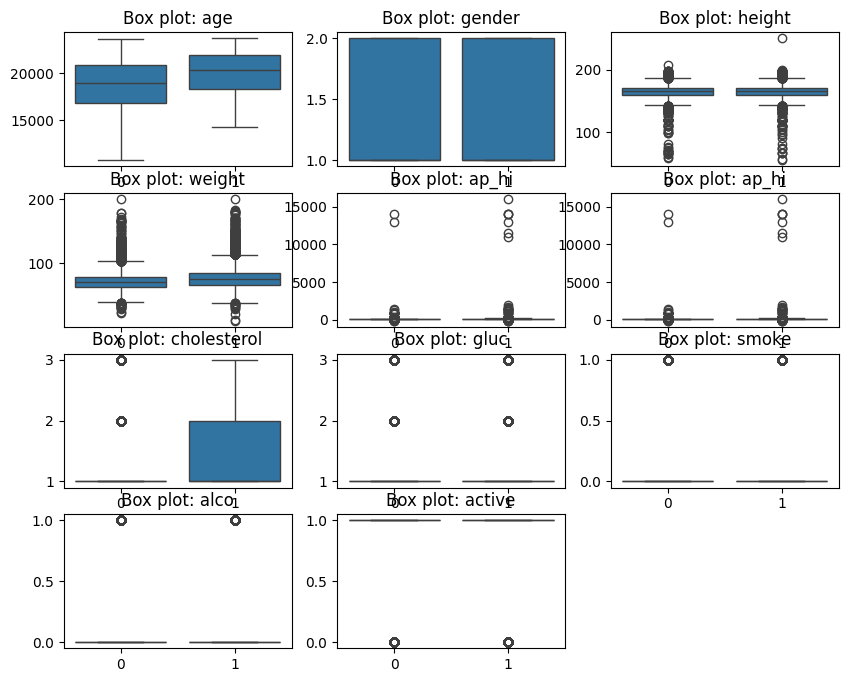

In [86]:
N_COLS = 3
N_ROWS = math.ceil(len(INPUT_FEATURES) / N_COLS)

plt.figure(figsize=(10,8))

for i, feature in enumerate(INPUT_FEATURES):
    plt.subplot(N_ROWS, N_COLS, i+1)
    plt.title(f"Box plot: {feature}")
    sns.boxplot(df, x=TARGET, y=feature)
    plt.ylabel("")
    plt.xlabel('')

plt.show()

### Outliers

In [87]:
def plot_box(features, hue):
    ROW_WIDTH = 6
    temp = 0

    for num_feature in features:
        if temp == 0:
            plt.figure(figsize=(25,5))

        plt.subplot(1,ROW_WIDTH, temp + 1)
        plt.title(f"Box plot: {num_feature}")
        sns.boxplot(df, x=num_feature, hue=hue, palette='rocket')

        if temp == ROW_WIDTH - 1:
            plt.show()

        temp = (temp + 1) % ROW_WIDTH

    if temp != ROW_WIDTH - 1:
        plt.show()

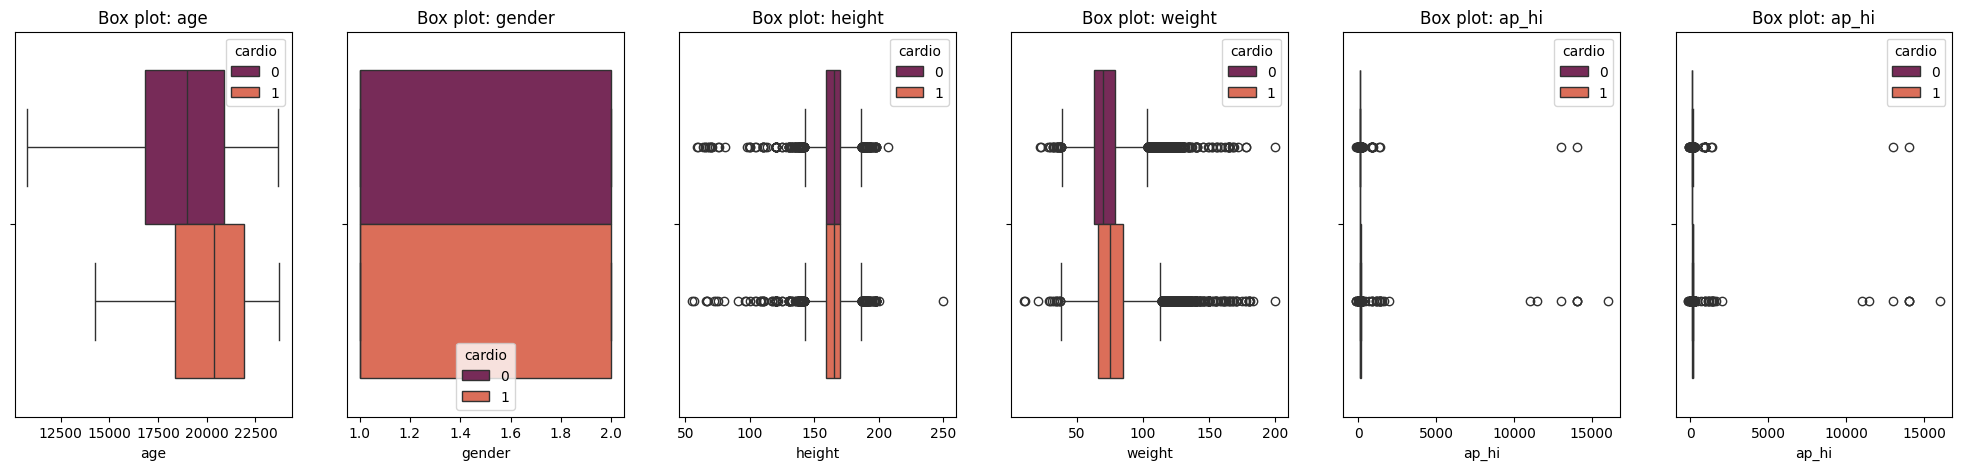

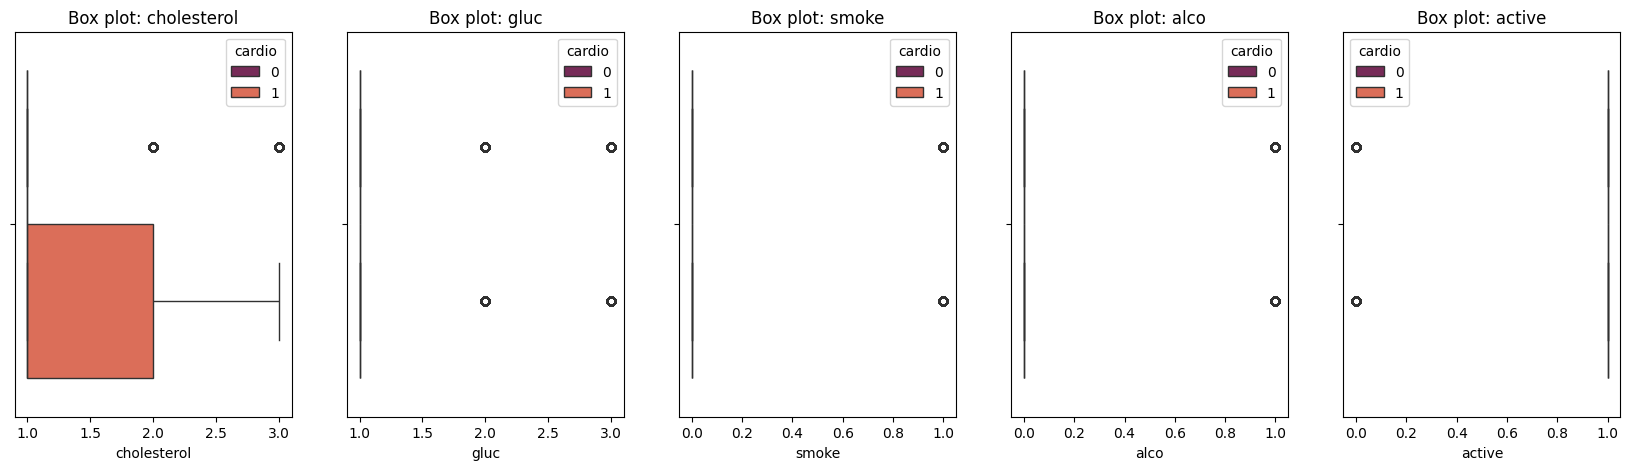

In [88]:
plot_box(INPUT_FEATURES, TARGET)

In [89]:
def IQR(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    min_v = Q1 - 1.5 * IQR
    max_v = Q3 + 1.5 * IQR

    return series.clip(lower=min_v, upper=max_v)

In [90]:
exclude = ['gluc','alco','smoke','colesterol','active']

for num_feature in [f for f in INPUT_FEATURES if f not in exclude]:
    for gender_category in df[TARGET].unique():
        mask = df[TARGET] == gender_category
        df.loc[mask, num_feature] = IQR(df.loc[mask, num_feature])

/tmp/ipykernel_28100/160621486.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[168. 156. 151. ... 159. 168. 170.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, num_feature] = IQR(df.loc[mask, num_feature])


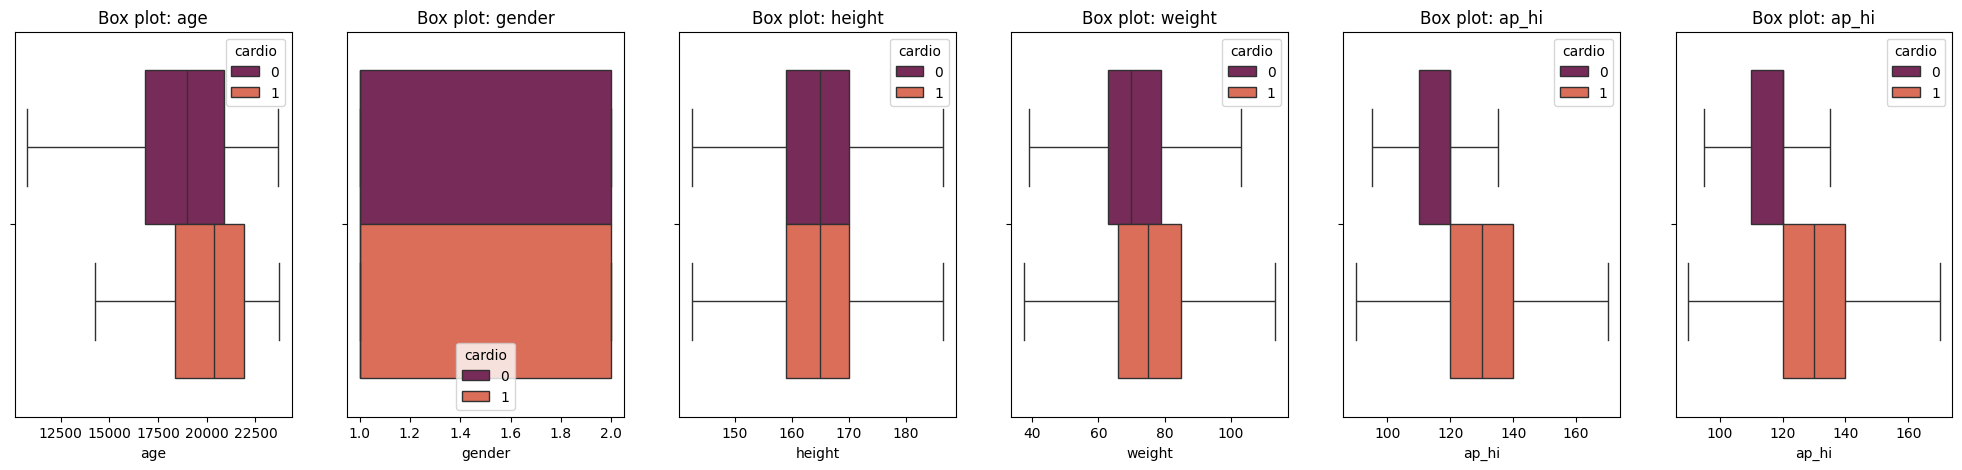

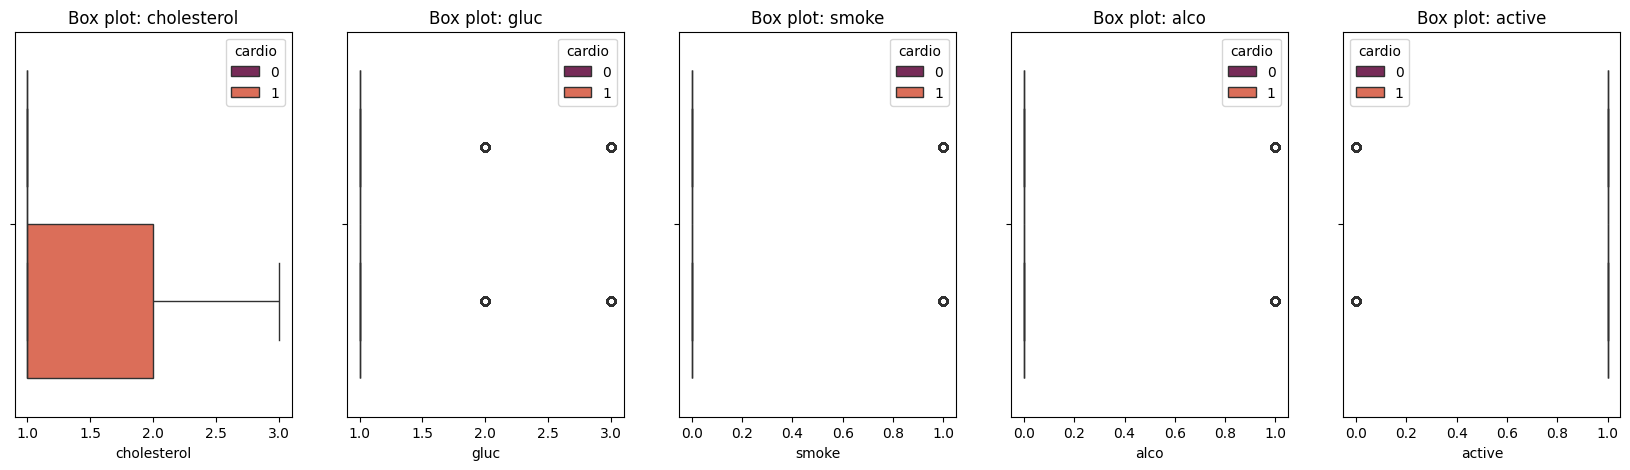

In [91]:
plot_box(INPUT_FEATURES, TARGET)

### Feature Engineering

In [92]:
INPUT_FEATURES

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_hi',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active']

In [93]:
df.head(5)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168.0,62.0,110,80,1,1,0,0,1,0
1,20228,1,156.0,85.0,140,90,3,1,0,0,1,1
2,18857,1,165.0,64.0,130,70,3,1,0,0,0,1
3,17623,2,169.0,82.0,150,100,1,1,0,0,1,1
4,17474,1,156.0,56.0,100,60,1,1,0,0,0,0


In [94]:
## days to age
df['age_years'] = (df['age'] / 365).astype(int)
df[['age', 'age_years']]

,age,age_years
0,18393,50
1,20228,55
2,18857,51
3,17623,48
4,17474,47
...,...,...
69995,19240,52
69996,22601,61
69997,19066,52
69998,22431,61


In [95]:
# Height
df['height'] = df['height']/100

In [96]:
# BMI
df['bmi'] = df['weight']/(df['height']**2)

In [97]:
# Pulse Pressure = Systolic - Diastoli
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

In [98]:

df['health_index'] = (df['active'] * 1) - (df['smoke'] * 0.5) - (df['alco'] * 0.5)

In [99]:
df['cholesterol_gluc_interaction'] = df['cholesterol'] * df['gluc']

In [100]:
new_features = [
    'age_years',
    'age_years',
    'bmi',
    'pulse_pressure',
    'health_index',
    'cholesterol_gluc_interaction'
]
INPUT_FEATURES = INPUT_FEATURES + [f for f in new_features if f not in INPUT_FEATURES]

In [101]:
df = df.drop(columns = 'age') 

In [102]:
df = df.drop(columns = 'height')

In [103]:
df.columns

Index(['gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'cardio', 'age_years', 'bmi', 'pulse_pressure',
       'health_index', 'cholesterol_gluc_interaction'],
      dtype='object')

In [104]:
INPUT=['gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'age_years', 'bmi', 'pulse_pressure',
       'health_index', 'cholesterol_gluc_interaction']

In [105]:
INPUT

['gender',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_years',
 'bmi',
 'pulse_pressure',
 'health_index',
 'cholesterol_gluc_interaction']

In [106]:
df

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
0,2,62.0,110,80,1,1,0,0,1,0,50,21.967120,30,1.0,1
1,1,85.0,140,90,3,1,0,0,1,1,55,34.927679,50,1.0,3
2,1,64.0,130,70,3,1,0,0,0,1,51,23.507805,60,0.0,3
3,2,82.0,150,100,1,1,0,0,1,1,48,28.710479,50,1.0,1
4,1,56.0,100,60,1,1,0,0,0,0,47,23.011177,40,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,76.0,120,80,1,1,1,0,1,0,52,26.927438,40,0.5,1
69996,1,113.5,140,90,2,2,0,0,1,1,61,45.465470,50,1.0,4
69997,2,105.0,170,90,3,1,0,1,0,1,52,31.353579,80,-0.5,3
69998,1,72.0,135,80,1,2,0,0,0,1,61,27.099251,55,0.0,2


### Correlation Matrix 

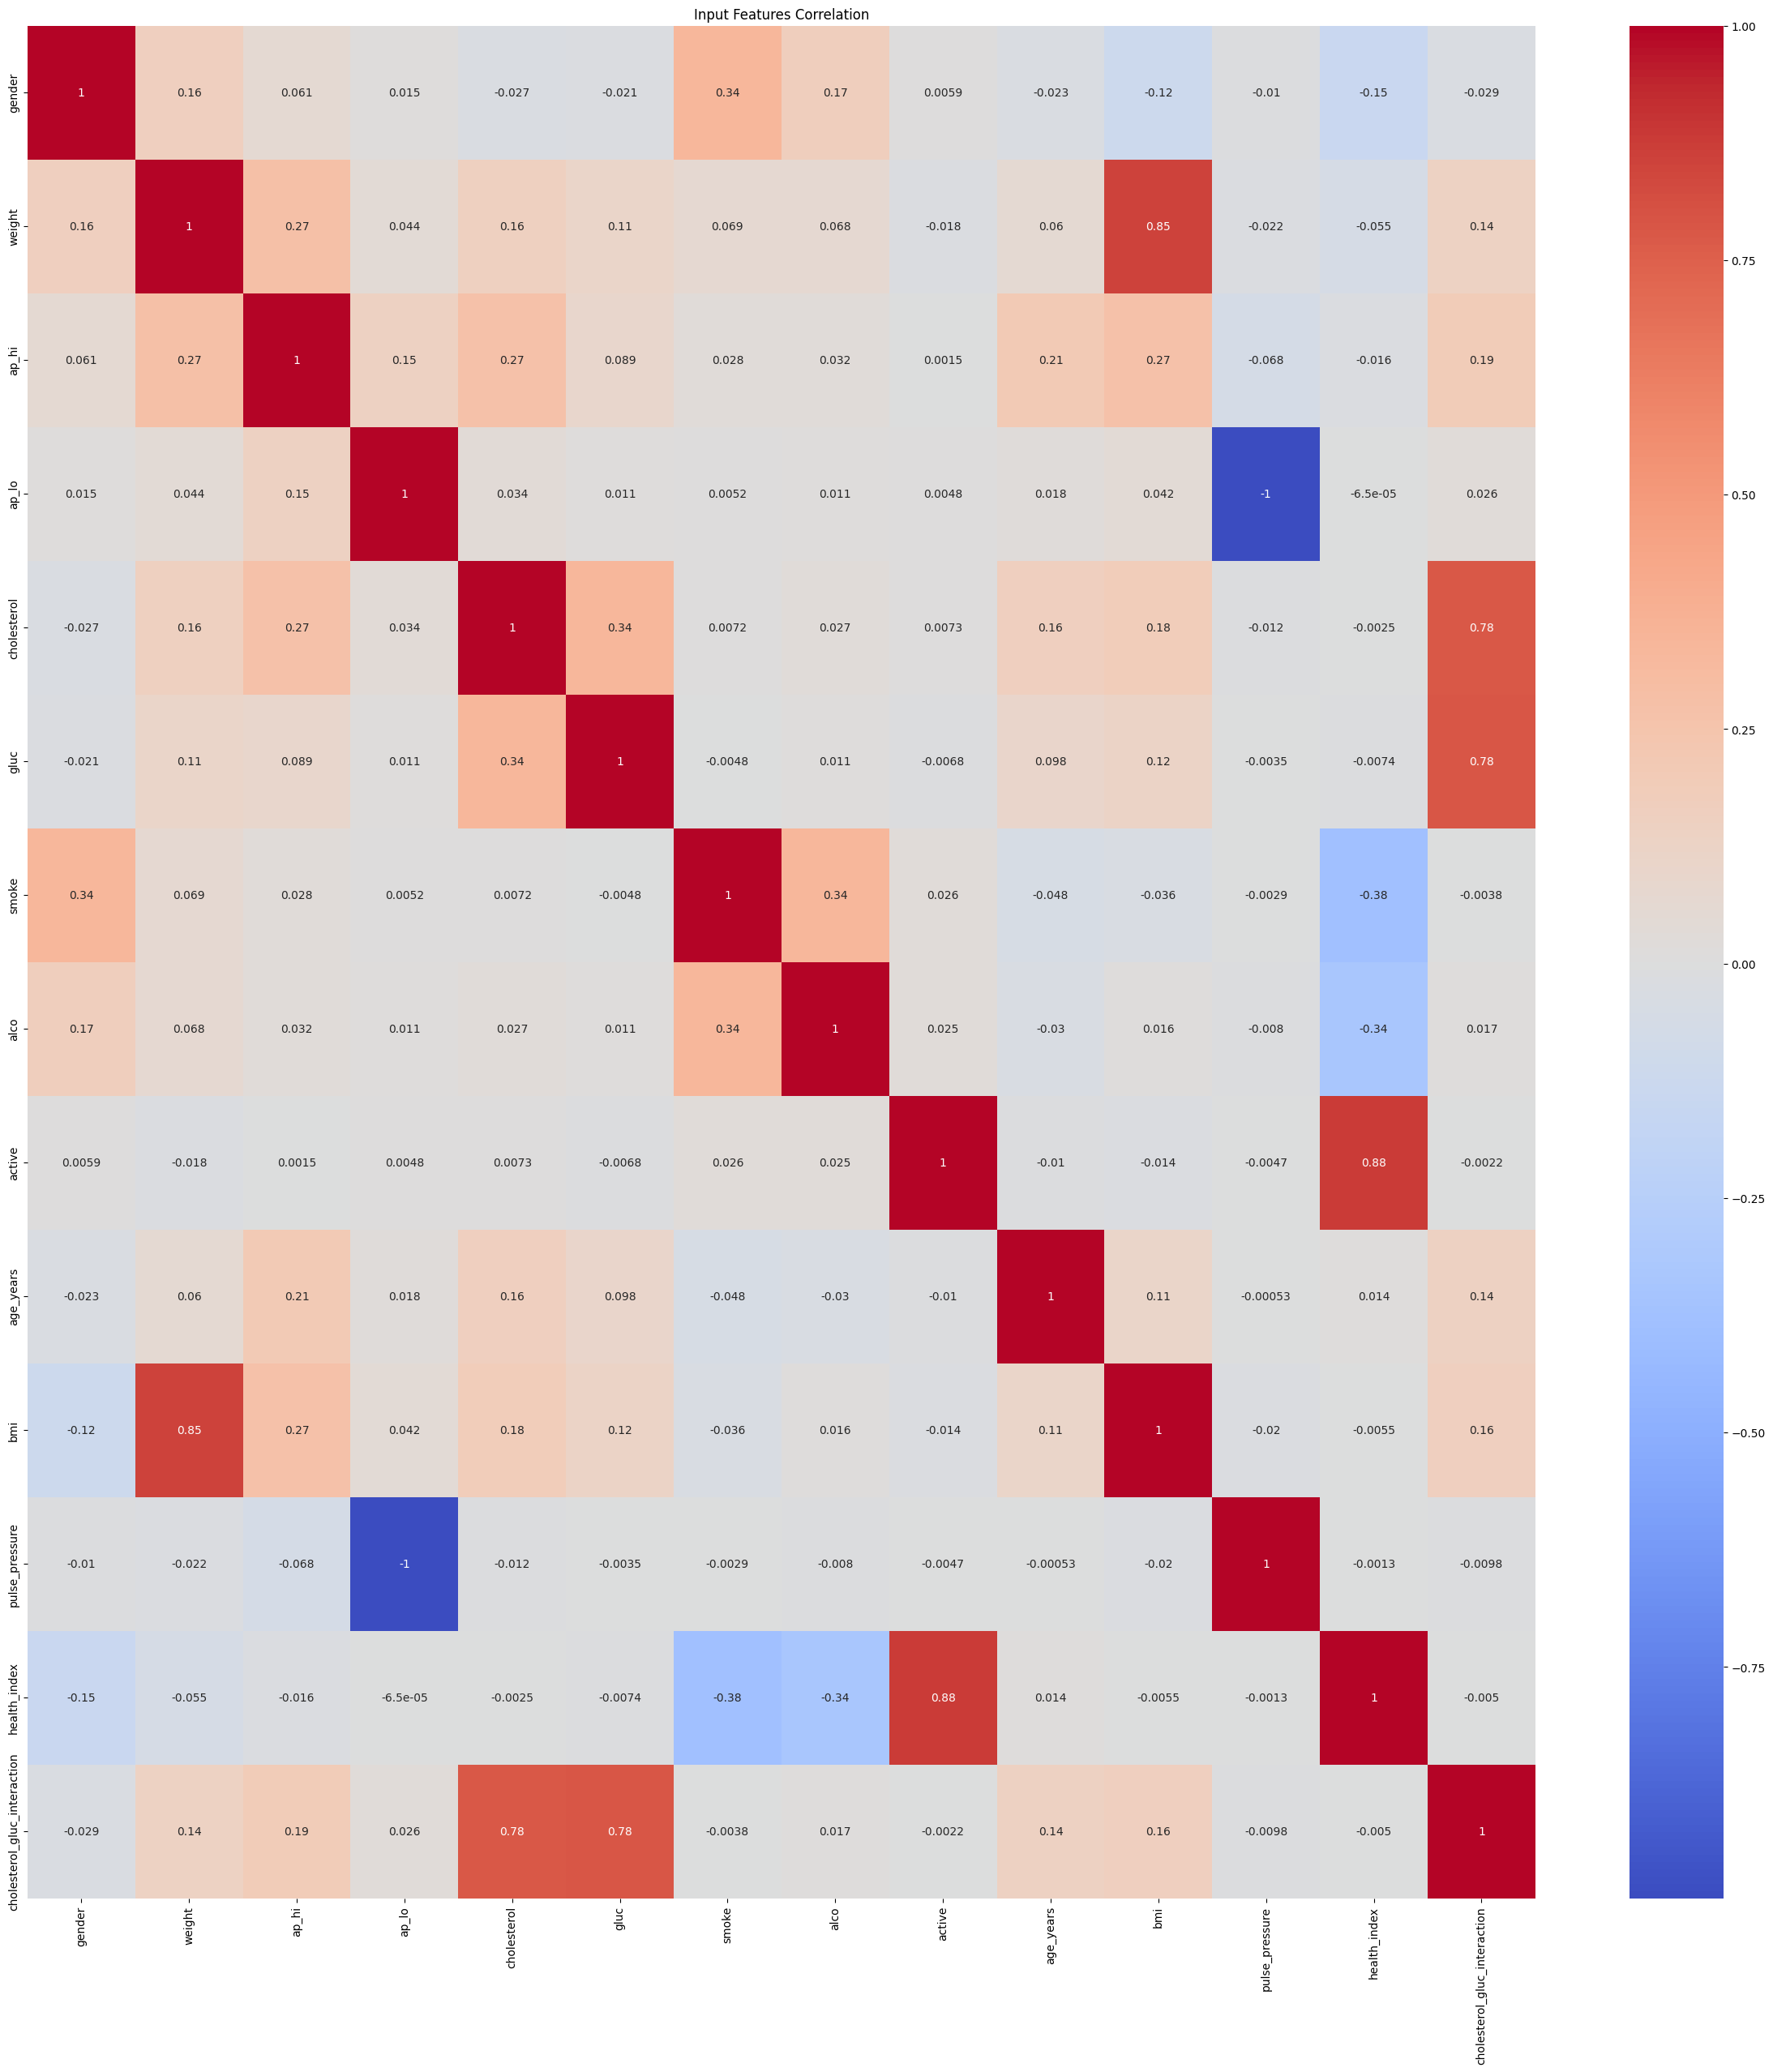

In [107]:
plt.figure(figsize = (30,30))
plt.title("Input Features Correlation")
sns.heatmap(
    df[INPUT].corr(),
    annot=True,
    cmap='coolwarm',
)
plt.show()

In [108]:
from sklearn.feature_selection import f_classif

### F1 Test

In [109]:
# F-value: Measures how much the means between groups differ relative to the variance within the groups. Higher = more likely the feature is important.

# p-value: Probability that the observed difference is due to chance.

# p < 0.05 → Statistically significant

# p ≥ 0.05 → Not significant

f_values, p_values = f_classif(df[INPUT], df[TARGET])

for i in range(len(INPUT)):
    print(f"{INPUT[i]:15s}: F-value = {f_values[i]:6.3f}, p-value = {p_values[i]:3.3f}")

gender         : F-value =  4.520, p-value = 0.033
weight         : F-value = 2699.317, p-value = 0.000
ap_hi          : F-value = 21919.396, p-value = 0.000
ap_lo          : F-value = 303.506, p-value = 0.000
cholesterol    : F-value = 15551.396, p-value = 0.000
gluc           : F-value = 562.088, p-value = 0.000
smoke          : F-value = 16.887, p-value = 0.000
alco           : F-value =  3.796, p-value = 0.051
active         : F-value = 89.125, p-value = 0.000
age_years      : F-value = 4202.349, p-value = 0.000
bmi            : F-value = 3013.511, p-value = 0.000
pulse_pressure : F-value = 45.673, p-value = 0.000
health_index   : F-value = 44.221, p-value = 0.000
cholesterol_gluc_interaction: F-value = 6922.787, p-value = 0.000


### Scaling

In [110]:
df.describe()

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,1.349648,73.966719,126.232937,96.636261,1.258632,1.226535,0.088159,0.053790,0.803718,0.499771,52.840874,27.403384,29.596676,0.732744,1.661956
std,0.476862,13.566176,15.595660,188.504581,0.606801,0.572353,0.283528,0.225604,0.397187,0.500004,6.767103,4.983222,186.807201,0.443010,1.622143
min,1.000000,37.500000,90.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,11.835627,-10830.000000,-1.000000,1.000000
25%,1.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115,40.000000,0.500000,1.000000
50%,1.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.395803,40.000000,1.000000,1.000000
75%,2.000000,82.000000,135.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.120482,50.000000,1.000000,2.000000
max,2.000000,113.500000,170.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,55.894121,170.000000,1.000000,9.000000


In [111]:
df.head()

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
0,2,62.0,110,80,1,1,0,0,1,0,50,21.967120,30,1.0,1
1,1,85.0,140,90,3,1,0,0,1,1,55,34.927679,50,1.0,3
2,1,64.0,130,70,3,1,0,0,0,1,51,23.507805,60,0.0,3
3,2,82.0,150,100,1,1,0,0,1,1,48,28.710479,50,1.0,1
4,1,56.0,100,60,1,1,0,0,0,0,47,23.011177,40,0.0,1


In [112]:
df

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
0,2,62.0,110,80,1,1,0,0,1,0,50,21.967120,30,1.0,1
1,1,85.0,140,90,3,1,0,0,1,1,55,34.927679,50,1.0,3
2,1,64.0,130,70,3,1,0,0,0,1,51,23.507805,60,0.0,3
3,2,82.0,150,100,1,1,0,0,1,1,48,28.710479,50,1.0,1
4,1,56.0,100,60,1,1,0,0,0,0,47,23.011177,40,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,76.0,120,80,1,1,1,0,1,0,52,26.927438,40,0.5,1
69996,1,113.5,140,90,2,2,0,0,1,1,61,45.465470,50,1.0,4
69997,2,105.0,170,90,3,1,0,1,0,1,52,31.353579,80,-0.5,3
69998,1,72.0,135,80,1,2,0,0,0,1,61,27.099251,55,0.0,2


In [113]:
df.to_csv("CardioPreprocessing.csv")

### Data Splitting

In [114]:
from sklearn.model_selection import train_test_split

In [115]:
X_train,X_test,Y_train,Y_test = train_test_split(
    df.drop(TARGET, axis=1),
    df.loc[:,TARGET],
    test_size = 0.25,
    random_state=1234,
    stratify=df.loc[:,TARGET]
)

In [116]:
print(f"{X_train.shape= }")
print(f"{Y_train.shape= }")
print(f"{X_test.shape= }")
print(f"{Y_test.shape= }")

X_train.shape= (52482, 14)
Y_train.shape= (52482,)
X_test.shape= (17494, 14)
Y_test.shape= (17494,)


In [117]:
Y_train.value_counts()

cardio
0    26253
1    26229
Name: count, dtype: int64

In [118]:
Y_test.value_counts()

cardio
0    8751
1    8743
Name: count, dtype: int64

In [119]:
list(X_train.columns)

['gender',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_years',
 'bmi',
 'pulse_pressure',
 'health_index',
 'cholesterol_gluc_interaction']

In [120]:
df_small = df.sample(7000, random_state=42) #full dataset load nai thato
df_small

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,health_index,cholesterol_gluc_interaction
54830,1,85.0,130,80,3,1,0,0,1,1,53,36.790166,50,1.0,3
56377,2,60.0,110,80,1,1,0,0,1,0,43,22.038567,30,1.0,1
49884,1,76.0,110,70,3,2,0,0,1,1,55,32.894737,40,1.0,6
35252,2,80.0,135,90,1,1,0,0,1,0,58,27.681661,45,1.0,1
56787,2,76.0,140,90,1,1,0,0,1,1,46,26.927438,50,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7873,1,63.0,110,70,1,1,0,1,1,0,46,22.321429,40,0.5,1
39807,1,75.0,120,80,1,1,0,0,1,0,54,25.951557,40,1.0,1
12800,1,75.0,120,80,1,3,0,0,1,0,50,27.217303,40,1.0,3
30284,1,67.0,110,70,1,1,0,0,1,0,52,29.777778,40,1.0,1


In [121]:
X = df_small.drop(TARGET, axis=1)
y = df_small[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=1234,
    stratify=y
)


In [122]:
train_df = X_train.copy()
train_df[TARGET] = y_train

test_df = X_test.copy()
test_df[TARGET] = y_test

train_data = train_df.to_numpy()
test_data = test_df.to_numpy()


In [123]:
import numpy as np

def gini_index(groups, classes):
    total = sum(len(group) for group in groups)
    gini = 0.0

    for group in groups:
        size = len(group)
        if size == 0:
            continue
        score = 0.0
        for class_val in classes:
            p = (group[:, -1] == class_val).sum() / size
            score += p * p
        gini += (1 - score) * (size / total)
    return gini


def test_split(index, value, dataset):
    left = dataset[dataset[:, index] < value]
    right = dataset[dataset[:, index] >= value]
    return left, right


def get_best_split(dataset):
    class_values = np.unique(dataset[:, -1])
    best_index, best_value, best_score, best_groups = None, None, 1e9, None

    for index in range(dataset.shape[1] - 1):
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini = gini_index(groups, class_values)
            if gini < best_score:
                best_index = index
                best_value = row[index]
                best_score = gini
                best_groups = groups

    return {'index': best_index, 'value': best_value, 'groups': best_groups}


def to_terminal(group):
    outcomes = [row[-1] for row in group]
    return max(set(outcomes), key=outcomes.count)


def split(node, max_depth, min_size, depth):
    left, right = node['groups']
    del node['groups']

    if len(left) == 0 or len(right) == 0:
        node['left'] = node['right'] = to_terminal(
            np.vstack((left, right))
        )
        return

    if depth >= max_depth:
        node['left'], node['right'] = to_terminal(left), to_terminal(right)
        return

    if len(left) <= min_size:
        node['left'] = to_terminal(left)
    else:
        node['left'] = get_best_split(left)
        split(node['left'], max_depth, min_size, depth + 1)

    if len(right) <= min_size:
        node['right'] = to_terminal(right)
    else:
        node['right'] = get_best_split(right)
        split(node['right'], max_depth, min_size, depth + 1)


def build_tree(train, max_depth, min_size):
    root = get_best_split(train)
    split(root, max_depth, min_size, 1)
    return root


def predict(node, row):
    # if leaf node
    if not isinstance(node, dict):
        return node

    # decision node
    if row[node['index']] < node['value']:
        return predict(node['left'], row)
    else:
        return predict(node['right'], row)


In [124]:
print("Training CART...")
tree = build_tree(train_data, max_depth=4, min_size=20)
print("Tree built")


Training CART...
Tree built


In [128]:
y_pred = [predict(tree, row) for row in test_data]

y_pred

[np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float6

In [126]:
print(train_data.shape)
print(test_data.shape)

(5250, 15)
(1750, 15)


In [127]:
from sklearn.metrics import accuracy_score

y_true = test_data[:, -1].astype(int)
y_pred = list(map(int, y_pred))

print("Accuracy:", accuracy_score(y_true, y_pred))


Accuracy: 0.82
